## <small>
Copyright (c) 2017-21 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning: A Visual Approach
## by Andrew Glassner, https://glassner.com
### Order: https://nostarch.com/deep-learning-visual-approach
### GitHub: https://github.com/blueberrymusic
------

### What's in this notebook

This notebook is provided as a “behind-the-scenes” look at code used to make some of the figures in this chapter. It is cleaned up a bit from the original code that I hacked together, and is only lightly commented. I wrote the code to be easy to interpret and understand, even for those who are new to Python. I tried never to be clever or even more efficient at the cost of being harder to understand. The code is in Python3, using the versions of libraries as of April 2021.

This notebook may contain additional code to create models and images not in the book. That material is included here to demonstrate additional techniques.

Note that I've included the output cells in this saved notebook, but Jupyter doesn't save the variables or data that were used to generate them. To recreate any cell's output, evaluate all the cells from the start up to that cell. A convenient way to experiment is to first choose "Restart & Run All" from the Kernel menu, so that everything's been defined and is up to date. Then you can experiment using the variables, data, functions, and other stuff defined in this notebook.

## Chapter 22: GANs - Notebook 1: Gaussians

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import math
import seaborn as sns ; sns.set()

In [22]:
# Make a File_Helper for saving and loading files.

save_files = False  # set True if you really want to write files

try:
    import os, sys, inspect

    current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
    sys.path.insert(0, os.path.dirname(current_dir))  # path to parent dir

    from DLBasics_Utilities import File_Helper
    print("Using real DLBasics_Utilities.File_Helper")

except ModuleNotFoundError:
    import os

    class File_Helper:
        def __init__(self, save_files=False):
            self.save_files = save_files
            self.INPUT_DIR = os.getcwd()

        def get_input_data_dir(self):
            d = self.INPUT_DIR
            print(f"get_input_data_dir (stub) -> {d}")
            return d

        def get_input_file_path(self, filename):
            path = os.path.join(self.INPUT_DIR, filename)
            print(f"get_input_file_path (stub) -> {path}")
            return path

        def save_figure(self, fig, filename, *args, **kwargs):
            if self.save_files and filename:
                import matplotlib.pyplot as plt
                fig.savefig(filename, *args, **kwargs)
                print(f"save_figure (stub) – saved figure to '{filename}'")
            else:
                print(f"save_figure (stub) – would save '{filename}', but skipping.")

        def load_model_weights(self, model, weights_filename):
            print(f"load_model_weights (stub) – no real weights file '{weights_filename}', returning False.")
            return False

        def save_model_weights(self, model, weights_filename):
            if self.save_files:
                model.save_weights(weights_filename)
                print(f"save_model_weights (stub) – saved weights to '{weights_filename}'")
            else:
                print(f"save_model_weights (stub) – would save '{weights_filename}', but skipping.")

        def __repr__(self):
            return f"<Stub File_Helper save_files={self.save_files}, INPUT_DIR='{self.INPUT_DIR}'>"

    print("Using stub File_Helper (DLBasics_Utilities not found)")

file_helper = File_Helper(save_files)
file_helper

Using stub File_Helper (DLBasics_Utilities not found)


<Stub File_Helper save_files=False, INPUT_DIR='/content'>

In [28]:
def make_gaussian_and_samples():
    np.random.seed(42)

    x = np.outer(np.linspace(3, 7, 40), np.ones(40))
    y = x.copy().T
    z = np.exp(-((x - 5) ** 2 + (y - 5) ** 2))

    fig = plt.figure(figsize=(10, 4))

    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot_surface(x, y, z, cmap='cool', rstride=1, cstride=1, linewidth=0)
    plt.xticks([3, 4, 5, 6, 7], [3, 4, 5, 6, 7])
    plt.yticks([3, 4, 5, 6, 7], [3, 4, 5, 6, 7])

    ax = fig.add_subplot(1, 2, 2)
    num_samples = 150
    gxy = np.random.normal(loc=(5, 5), size=(num_samples, 2))
    ax.scatter(gxy[:, 0], gxy[:, 1])
    circle1 = plt.Circle((5, 5), 1.0, color='black', lw=2, fill=False)
    ax.add_artist(circle1)
    plt.xlim(2, 8)
    plt.ylim(2, 8)

    file_helper.save_figure(fig, 'gblob-start')
    plt.show()

save_figure (stub) – would save 'gblob-start', but skipping.


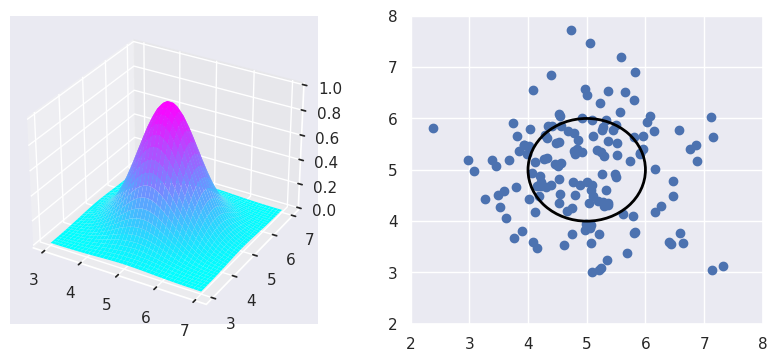

In [29]:
make_gaussian_and_samples()

In [30]:
def make_gaussian_onepoint():
    np.random.seed(42)
    fig = plt.figure(figsize=(5, 4.5))

    plt.scatter([6.3], [5.8], s=60)
    circle1 = plt.Circle((5, 5), 1.0, color='black', lw=2, fill=False)
    ax = fig.gca()
    ax.add_artist(circle1)
    plt.xlim(2, 8)
    plt.ylim(2, 8)

    file_helper.save_figure(fig, 'gblob-onepoint')
    plt.show()

save_figure (stub) – would save 'gblob-onepoint', but skipping.


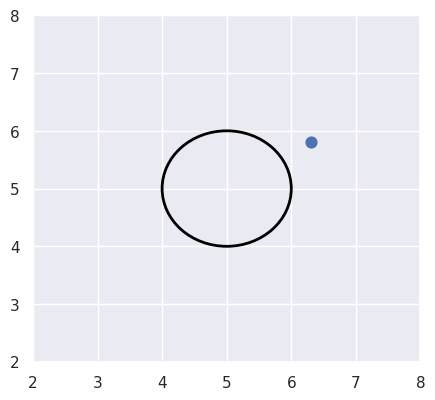

In [31]:
make_gaussian_onepoint()

In [35]:
def make_gaussian_misfits():
    np.random.seed(42)
    fig = plt.figure(figsize=(10, 3))
    num_samples = 35

    # 1: Cluster in top-left
    plt.subplot(1, 3, 1)
    gxy = np.random.normal(loc=(3.5, 6.5), scale=(0.5, 0.5), size=(num_samples, 2))
    plt.scatter(gxy[:, 0], gxy[:, 1])
    circle1 = plt.Circle((5, 5), 1.0, color='black', lw=2, fill=False)
    ax = fig.gca()
    ax.add_artist(circle1)
    plt.xlim(2, 8)
    plt.ylim(2, 8)

    # 2: Ring segment around the circle
    plt.subplot(1, 3, 2)
    gxy = []
    for _ in range(num_samples):
        theta = np.random.uniform(low=-0.3 * math.pi, high=0.4 * math.pi)
        r = np.random.uniform(low=1.5, high=2.2)
        xy = [5 + (r * math.cos(theta)), 5 + (r * math.sin(theta))]
        gxy.append(xy)
    gxy = np.array(gxy)
    plt.scatter(gxy[:, 0], gxy[:, 1])
    circle1 = plt.Circle((5, 5), 1.0, color='black', lw=2, fill=False)
    ax = fig.gca()
    ax.add_artist(circle1)
    plt.xlim(2, 8)
    plt.ylim(2, 8)

    # 3: Uniform in the box
    plt.subplot(1, 3, 3)
    gxy = np.random.uniform(low=2.5, high=7.5, size=(num_samples, 2))
    plt.scatter(gxy[:, 0], gxy[:, 1])
    circle1 = plt.Circle((5, 5), 1.0, color='black', lw=2, fill=False)
    ax = fig.gca()
    ax.add_artist(circle1)
    plt.xlim(2, 8)
    plt.ylim(2, 8)

    # Save figure correctly: pass fig and filename
    file_helper.save_figure(fig, 'gblob-misfits')
    plt.show()

save_figure (stub) – would save 'gblob-misfits', but skipping.


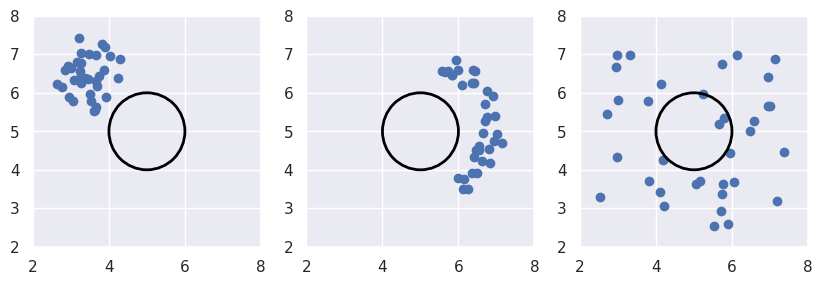

In [36]:
make_gaussian_misfits()